# investalyze: data log (findings + decisions)

A running, reproducible record of data quirks (characteristics of the data itself) and the decisions
they drive. Each entry says what the quirk is, why it exists, and that it is genuine data, not a mistake.
One markdown cell + one code cell per entry, newest on top. Committed with outputs.

Status legend: ✅ understood · 🔶 open question · ❓ to verify

Entry template: header `## <ticker / topic>: <one-line>  <status>`, then **What:** and **Why:**.

## Index

- `^MRV` (Merval): index level spans ~8 orders of magnitude ✅

In [4]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

from helpers import connect_readonly, load_ticker_rows

con = connect_readonly()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## `^MRV` (Merval, Argentina): index level spans ~8 orders of magnitude ✅

**What**: `^MRV`, the Argentine Merval index, has an enormous **dynamic range**: its nominal level runs
from ~0.03 (1988) to ~3.3M (2026), roughly **8 orders of magnitude**. This is **genuine data, not a feed
glitch**.

**Why**: decades of Argentine **hyperinflation** plus several **currency redenominations** inflate the
index.

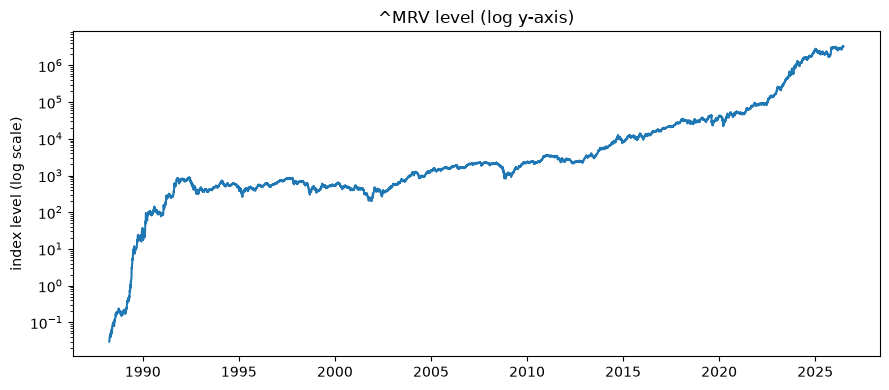

level range 0.03 to 3,353,008, span x111,766,925 (~8.0 orders of magnitude)


In [5]:
TICKER = '^MRV'

mrv = load_ticker_rows(con, 'market_data', TICKER).sort_values('Date')
price = mrv['C'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mrv['Date'], price)
ax.set_yscale('log')
ax.set_title(f'{TICKER} level (log y-axis)')
ax.set_ylabel('index level (log scale)')
plt.tight_layout()
plt.show()

span = price.max() / price.min()
print(f'level range {price.min():g} to {price.max():,.0f}, span x{span:,.0f} (~{np.log10(span):.1f} orders of magnitude)')

---